In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.preprocessing import MinMaxScaler


In [2]:
# Classification dataset (non-linear)
X_cls, y_cls = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42
)
y_cls = y_cls.reshape(-1, 1)

scaler = MinMaxScaler()
X_cls = scaler.fit_transform(X_cls)

In [3]:
# Regression dataset
X_reg, y_reg = make_regression(
    n_samples=200,
    n_features=1,
    noise=15,
    random_state=42
)
y_reg = y_reg.reshape(-1, 1)
X_reg = scaler.fit_transform(X_reg)


In [4]:
#MLP FORWARD (ใช้ร่วมกันทุก algorithm)
def mlp_forward(X, w, n_input, n_hidden, task):
    idx = 0

    W1 = w[idx:idx+n_input*n_hidden].reshape(n_input, n_hidden)
    idx += n_input*n_hidden

    b1 = w[idx:idx+n_hidden].reshape(1, n_hidden)
    idx += n_hidden

    W2 = w[idx:idx+n_hidden].reshape(n_hidden, 1)
    idx += n_hidden

    b2 = w[idx:idx+1].reshape(1, 1)

    h = np.tanh(X @ W1 + b1)

    if task == "classification":
        y_hat = 1 / (1 + np.exp(-(h @ W2 + b2)))
    else:
        y_hat = h @ W2 + b2

    return y_hat


In [5]:
#LOSS / FITNESS FUNCTION
def mse(y, y_hat):
    return np.mean((y - y_hat)**2)

def fitness_function(w, X, y, n_input, n_hidden, task):
    y_hat = mlp_forward(X, w, n_input, n_hidden, task)
    return mse(y, y_hat)


#BINARY GENETIC ALGORITHM

In [6]:
def binary_ga(fitness_fn, dim, bounds, pop_size=30, generations=100):
    n_bits = 10
    pop = np.random.randint(0, 2, (pop_size, dim * n_bits))

    def decode(ind):
        real = []
        for i in range(dim):
            bits = ind[i*n_bits:(i+1)*n_bits]
            val = int("".join(bits.astype(str)), 2)
            real_val = bounds[0] + (bounds[1]-bounds[0]) * val / (2**n_bits - 1)
            real.append(real_val)
        return np.array(real)

    for _ in range(generations):
        decoded = np.array([decode(ind) for ind in pop])
        fitness = np.array([fitness_fn(ind) for ind in decoded])

        idx = np.argsort(fitness)
        pop = pop[idx]

        for i in range(pop_size//2, pop_size):
            p1, p2 = pop[np.random.randint(0, pop_size//2, 2)]
            cut = np.random.randint(1, len(p1)-1)
            child = np.concatenate([p1[:cut], p2[cut:]])

            mut = np.random.rand(len(child)) < 0.01
            child[mut] = 1 - child[mut]

            pop[i] = child

    best = decode(pop[0])
    return best


#REAL-CODED GA

In [7]:
def real_ga(fitness_fn, dim, bounds, pop_size=30, generations=100):
    pop = np.random.uniform(bounds[0], bounds[1], (pop_size, dim))

    for _ in range(generations):
        fitness = np.array([fitness_fn(ind) for ind in pop])
        idx = np.argsort(fitness)
        pop = pop[idx]

        for i in range(pop_size//2, pop_size):
            p1, p2 = pop[np.random.randint(0, pop_size//2, 2)]
            child = (p1 + p2) / 2
            child += np.random.normal(0, 0.1, dim)
            pop[i] = child

    return pop[0]


#BASIC DIFFERENTIAL EVOLUTION

In [8]:
def basic_de(fitness_fn, dim, bounds, pop_size=30, generations=100, F=0.5, CR=0.9):
    pop = np.random.uniform(bounds[0], bounds[1], (pop_size, dim))
    scores = np.array([fitness_fn(ind) for ind in pop])

    for _ in range(generations):
        for i in range(pop_size):
            idxs = [idx for idx in range(pop_size) if idx != i]
            r1, r2, r3 = pop[np.random.choice(idxs, 3, replace=False)]

            v = r1 + F * (r2 - r3)
            u = np.where(np.random.rand(dim) < CR, v, pop[i])

            score = fitness_fn(u)
            if score < scores[i]:
                pop[i] = u
                scores[i] = score

    return pop[np.argmin(scores)]


#ADAPTIVE DIFFERENTIAL EVOLUTION

In [9]:
def adaptive_de(fitness_fn, dim, bounds, pop_size=30, generations=100):
    pop = np.random.uniform(bounds[0], bounds[1], (pop_size, dim))
    scores = np.array([fitness_fn(ind) for ind in pop])

    for _ in range(generations):
        for i in range(pop_size):
            F = np.random.uniform(0.4, 1.0)
            CR = np.random.uniform(0.1, 0.9)

            idxs = [idx for idx in range(pop_size) if idx != i]
            r1, r2, r3 = pop[np.random.choice(idxs, 3, replace=False)]

            v = r1 + F * (r2 - r3)
            u = np.where(np.random.rand(dim) < CR, v, pop[i])

            score = fitness_fn(u)
            if score < scores[i]:
                pop[i] = u
                scores[i] = score

    return pop[np.argmin(scores)]


#RUN EXPERIMENT (ตัวอย่าง Classification)

In [10]:
n_input = X_cls.shape[1]
n_hidden = 10
dim = n_input*n_hidden + n_hidden + n_hidden + 1

fit = lambda w: fitness_function(
    w, X_cls, y_cls, n_input, n_hidden, "classification"
)

w_bga = binary_ga(fit, dim, (-2, 2))
w_rga = real_ga(fit, dim, (-2, 2))
w_de  = basic_de(fit, dim, (-2, 2))
w_ade = adaptive_de(fit, dim, (-2, 2))


#Accuracy (Classification)

In [11]:
def accuracy(y, y_hat):
    y_pred = (y_hat >= 0.5).astype(int)
    return np.mean(y_pred == y)


#Evaluate ทุก algorithm

In [12]:
# ----- Binary GA -----
y_hat_bga = mlp_forward(X_cls, w_bga, n_input, n_hidden, "classification")
loss_bga = mse(y_cls, y_hat_bga)
acc_bga = accuracy(y_cls, y_hat_bga)

# ----- Real GA -----
y_hat_rga = mlp_forward(X_cls, w_rga, n_input, n_hidden, "classification")
loss_rga = mse(y_cls, y_hat_rga)
acc_rga = accuracy(y_cls, y_hat_rga)

# ----- Basic DE -----
y_hat_de = mlp_forward(X_cls, w_de, n_input, n_hidden, "classification")
loss_de = mse(y_cls, y_hat_de)
acc_de = accuracy(y_cls, y_hat_de)

# ----- Adaptive DE -----
y_hat_ade = mlp_forward(X_cls, w_ade, n_input, n_hidden, "classification")
loss_ade = mse(y_cls, y_hat_ade)
acc_ade = accuracy(y_cls, y_hat_ade)


In [13]:
print("=== Classification Results ===")
print(f"Binary GA      | Loss: {loss_bga:.4f} | Accuracy: {acc_bga*100:.2f}%")
print(f"Real-coded GA  | Loss: {loss_rga:.4f} | Accuracy: {acc_rga*100:.2f}%")
print(f"Basic DE       | Loss: {loss_de:.4f} | Accuracy: {acc_de*100:.2f}%")
print(f"Adaptive DE    | Loss: {loss_ade:.4f} | Accuracy: {acc_ade*100:.2f}%")


=== Classification Results ===
Binary GA      | Loss: 0.1022 | Accuracy: 87.00%
Real-coded GA  | Loss: 0.1022 | Accuracy: 86.50%
Basic DE       | Loss: 0.0965 | Accuracy: 89.00%
Adaptive DE    | Loss: 0.1025 | Accuracy: 86.00%


#ตัว classification result แบบมีเวลา

In [14]:
import numpy as np
import time
from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler

X_cls, y_cls = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42
)
y_cls = y_cls.reshape(-1, 1)

scaler = MinMaxScaler()
X_cls = scaler.fit_transform(X_cls)


In [15]:
print(X_cls.shape, y_cls.shape)

(200, 2) (200, 1)


In [16]:
def mlp_forward(X, w, n_input, n_hidden, task):
    idx = 0

    W1 = w[idx:idx+n_input*n_hidden].reshape(n_input, n_hidden)
    idx += n_input*n_hidden

    b1 = w[idx:idx+n_hidden].reshape(1, n_hidden)
    idx += n_hidden

    W2 = w[idx:idx+n_hidden].reshape(n_hidden, 1)
    idx += n_hidden

    b2 = w[idx:idx+1].reshape(1, 1)

    h = np.tanh(X @ W1 + b1)

    if task == "classification":
        y_hat = 1 / (1 + np.exp(-(h @ W2 + b2)))
    else:
        y_hat = h @ W2 + b2

    return y_hat


In [17]:
def mse(y, y_hat):
    return np.mean((y - y_hat)**2)

def accuracy(y, y_hat):
    y_pred = (y_hat >= 0.5).astype(int)
    return np.mean(y_pred == y)

def objective(w, X, y, n_input, n_hidden, task):
    y_hat = mlp_forward(X, w, n_input, n_hidden, task)
    return mse(y, y_hat)


In [18]:
n_input = X_cls.shape[1]
n_hidden = 10
dim = n_input*n_hidden + n_hidden + n_hidden + 1

def f_cls(w):
    return objective(w, X_cls, y_cls, n_input, n_hidden, "classification")


In [19]:
N_RUNS = 20

results = {
    "Binary GA": {"loss": [], "acc": [], "time": []},
    "Real GA": {"loss": [], "acc": [], "time": []},
    "Basic DE": {"loss": [], "acc": [], "time": []},
    "Adaptive DE": {"loss": [], "acc": [], "time": []},
}

for run in range(N_RUNS):

    # ===== Binary GA =====
    start = time.time()
    w = binary_ga(f_cls, dim, (-2, 2))
    elapsed = time.time() - start

    y_hat = mlp_forward(X_cls, w, n_input, n_hidden, "classification")
    results["Binary GA"]["loss"].append(mse(y_cls, y_hat))
    results["Binary GA"]["acc"].append(accuracy(y_cls, y_hat))
    results["Binary GA"]["time"].append(elapsed)

    # ===== Real GA =====
    start = time.time()
    w = real_ga(f_cls, dim, (-2, 2))
    elapsed = time.time() - start

    y_hat = mlp_forward(X_cls, w, n_input, n_hidden, "classification")
    results["Real GA"]["loss"].append(mse(y_cls, y_hat))
    results["Real GA"]["acc"].append(accuracy(y_cls, y_hat))
    results["Real GA"]["time"].append(elapsed)

    # ===== Basic DE =====
    start = time.time()
    w = basic_de(f_cls, dim, (-2, 2))
    elapsed = time.time() - start

    y_hat = mlp_forward(X_cls, w, n_input, n_hidden, "classification")
    results["Basic DE"]["loss"].append(mse(y_cls, y_hat))
    results["Basic DE"]["acc"].append(accuracy(y_cls, y_hat))
    results["Basic DE"]["time"].append(elapsed)

    # ===== Adaptive DE =====
    start = time.time()
    w = adaptive_de(f_cls, dim, (-2, 2))
    elapsed = time.time() - start

    y_hat = mlp_forward(X_cls, w, n_input, n_hidden, "classification")
    results["Adaptive DE"]["loss"].append(mse(y_cls, y_hat))
    results["Adaptive DE"]["acc"].append(accuracy(y_cls, y_hat))
    results["Adaptive DE"]["time"].append(elapsed)


In [20]:
for algo in results:
    print(algo, len(results[algo]["loss"]))

Binary GA 20
Real GA 20
Basic DE 20
Adaptive DE 20


In [21]:
print("=== Classification Results (Mean ± Std over {} runs) ===".format(N_RUNS))

for algo in results:
    loss_mean = np.mean(results[algo]["loss"])
    loss_std  = np.std(results[algo]["loss"])

    acc_mean  = np.mean(results[algo]["acc"]) * 100
    acc_std   = np.std(results[algo]["acc"]) * 100

    time_mean = np.mean(results[algo]["time"])
    time_std  = np.std(results[algo]["time"])

    print(
        f"{algo:<12} | "
        f"Loss: {loss_mean:.4f} ± {loss_std:.4f} | "
        f"Acc: {acc_mean:.2f}% ± {acc_std:.2f}% | "
        f"Time: {time_mean:.2f}s ± {time_std:.2f}s"
    )

=== Classification Results (Mean ± Std over 20 runs) ===
Binary GA    | Loss: 0.1030 ± 0.0012 | Acc: 87.45% ± 0.85% | Time: 2.12s ± 0.85s
Real GA      | Loss: 0.1027 ± 0.0009 | Acc: 86.95% ± 0.69% | Time: 0.63s ± 0.33s
Basic DE     | Loss: 0.0989 ± 0.0024 | Acc: 88.10% ± 1.11% | Time: 0.77s ± 0.30s
Adaptive DE  | Loss: 0.1024 ± 0.0027 | Acc: 87.27% ± 1.32% | Time: 0.79s ± 0.22s


In [22]:
import numpy as np
import matplotlib.pyplot as plt

algos = list(results.keys())

mean_loss = [np.mean(results[a]["loss"]) for a in algos]
std_loss  = [np.std(results[a]["loss"])  for a in algos]

mean_acc = [np.mean(results[a]["acc"])*100 for a in algos]
std_acc  = [np.std(results[a]["acc"])*100  for a in algos]

mean_time = [np.mean(results[a]["time"]) for a in algos]
std_time  = [np.std(results[a]["time"])  for a in algos]


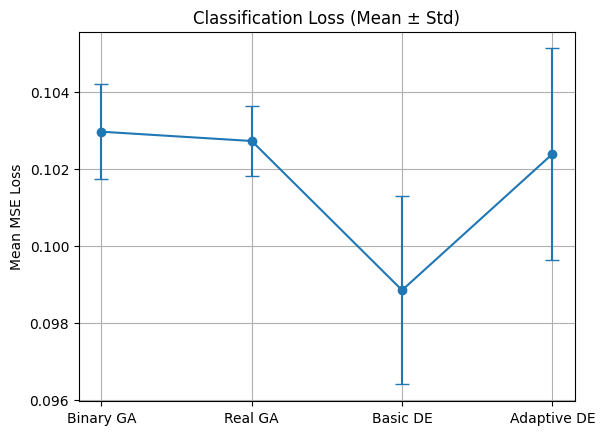

In [23]:
plt.figure()
plt.errorbar(
    algos,
    mean_loss,
    yerr=std_loss,
    marker='o',
    capsize=5
)
plt.ylabel("Mean MSE Loss")
plt.title("Classification Loss (Mean ± Std)")
plt.grid(True)
plt.show()


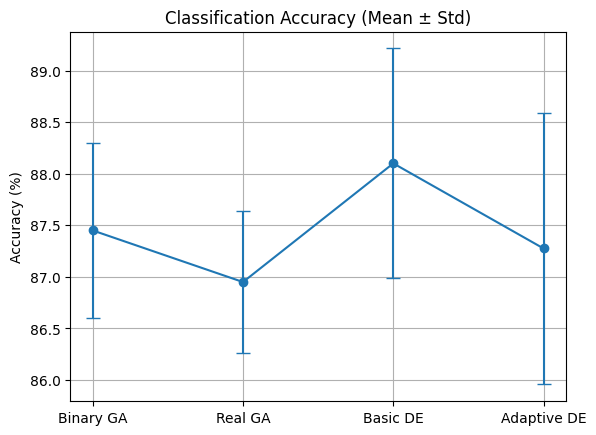

In [24]:
plt.figure()
plt.errorbar(
    algos,
    mean_acc,
    yerr=std_acc,
    marker='o',
    capsize=5
)
plt.ylabel("Accuracy (%)")
plt.title("Classification Accuracy (Mean ± Std)")
plt.grid(True)
plt.show()


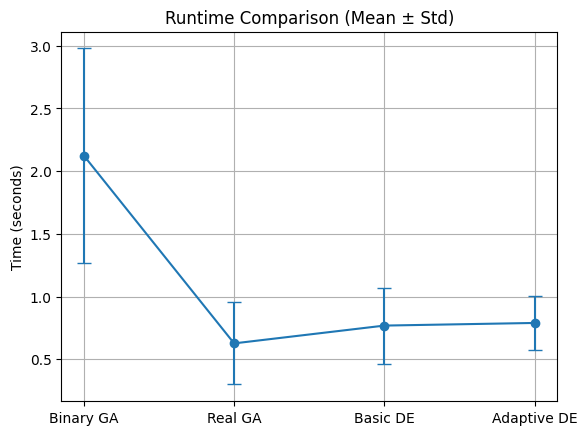

In [25]:
plt.figure()
plt.errorbar(
    algos,
    mean_time,
    yerr=std_time,
    marker='o',
    capsize=5
)
plt.ylabel("Time (seconds)")
plt.title("Runtime Comparison (Mean ± Std)")
plt.grid(True)
plt.show()

#Import + Regression Dataset

In [26]:
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.preprocessing import MinMaxScaler


In [27]:
# Regression dataset
X_reg, y_reg = make_regression(
    n_samples=200,
    n_features=1,
    noise=15,
    random_state=42
)

y_reg = y_reg.reshape(-1, 1)

scaler = MinMaxScaler()
X_reg = scaler.fit_transform(X_reg)


In [28]:
print(X_reg.shape, y_reg.shape)

(200, 1) (200, 1)


In [29]:
def mlp_forward(X, w, n_input, n_hidden, task):
    idx = 0

    W1 = w[idx:idx+n_input*n_hidden].reshape(n_input, n_hidden)
    idx += n_input*n_hidden

    b1 = w[idx:idx+n_hidden].reshape(1, n_hidden)
    idx += n_hidden

    W2 = w[idx:idx+n_hidden].reshape(n_hidden, 1)
    idx += n_hidden

    b2 = w[idx:idx+1].reshape(1, 1)

    h = np.tanh(X @ W1 + b1)

    if task == "regression":
        y_hat = h @ W2 + b2
    else:
        y_hat = 1 / (1 + np.exp(-(h @ W2 + b2)))

    return y_hat


In [30]:
def mse(y, y_hat):
    return np.mean((y - y_hat)**2)

def objective(w, X, y, n_input, n_hidden, task):
    y_hat = mlp_forward(X, w, n_input, n_hidden, task)
    return mse(y, y_hat)


In [31]:
n_input = X_reg.shape[1]
n_hidden = 10
dim = n_input*n_hidden + n_hidden + n_hidden + 1

def f_reg(w):
    return objective(w, X_reg, y_reg, n_input, n_hidden, "regression")


In [32]:
N_RUNS = 20

results_reg = {
    "Binary GA": {"loss": [], "time": []},
    "Real GA": {"loss": [], "time": []},
    "Basic DE": {"loss": [], "time": []},
    "Adaptive DE": {"loss": [], "time": []},
}

for run in range(N_RUNS):

    # ----- Binary GA -----
    start = time.time()
    w = binary_ga(f_reg, dim, (-2, 2))
    elapsed = time.time() - start

    y_hat = mlp_forward(X_reg, w, n_input, n_hidden, "regression")
    results_reg["Binary GA"]["loss"].append(mse(y_reg, y_hat))
    results_reg["Binary GA"]["time"].append(elapsed)

    # ----- Real GA -----
    start = time.time()
    w = real_ga(f_reg, dim, (-2, 2))
    elapsed = time.time() - start

    y_hat = mlp_forward(X_reg, w, n_input, n_hidden, "regression")
    results_reg["Real GA"]["loss"].append(mse(y_reg, y_hat))
    results_reg["Real GA"]["time"].append(elapsed)

    # ----- Basic DE -----
    start = time.time()
    w = basic_de(f_reg, dim, (-2, 2))
    elapsed = time.time() - start

    y_hat = mlp_forward(X_reg, w, n_input, n_hidden, "regression")
    results_reg["Basic DE"]["loss"].append(mse(y_reg, y_hat))
    results_reg["Basic DE"]["time"].append(elapsed)

    # ----- Adaptive DE -----
    start = time.time()
    w = adaptive_de(f_reg, dim, (-2, 2))
    elapsed = time.time() - start

    y_hat = mlp_forward(X_reg, w, n_input, n_hidden, "regression")
    results_reg["Adaptive DE"]["loss"].append(mse(y_reg, y_hat))
    results_reg["Adaptive DE"]["time"].append(elapsed)


In [33]:
print("=== Regression Results (Mean ± Std over {} runs) ===".format(N_RUNS))

for algo in results_reg:
    loss_mean = np.mean(results_reg[algo]["loss"])
    loss_std  = np.std(results_reg[algo]["loss"])

    time_mean = np.mean(results_reg[algo]["time"])
    time_std  = np.std(results_reg[algo]["time"])

    print(
        f"{algo:<12} | "
        f"MSE: {loss_mean:.4f} ± {loss_std:.4f} | "
        f"Time: {time_mean:.2f}s ± {time_std:.2f}s"
    )


=== Regression Results (Mean ± Std over 20 runs) ===
Binary GA    | MSE: 6032.4472 ± 38.0474 | Time: 1.55s ± 0.28s
Real GA      | MSE: 5879.2979 ± 92.0947 | Time: 0.55s ± 0.08s
Basic DE     | MSE: 484.5669 ± 124.9436 | Time: 0.68s ± 0.06s
Adaptive DE  | MSE: 601.2490 ± 161.5367 | Time: 0.72s ± 0.08s


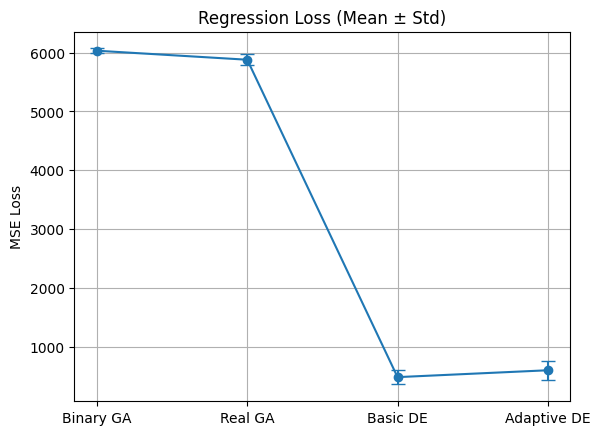

In [34]:
algos = list(results_reg.keys())
mean_loss = [np.mean(results_reg[a]["loss"]) for a in algos]
std_loss  = [np.std(results_reg[a]["loss"])  for a in algos]

plt.figure()
plt.errorbar(
    algos,
    mean_loss,
    yerr=std_loss,
    marker='o',
    capsize=5
)
plt.ylabel("MSE Loss")
plt.title("Regression Loss (Mean ± Std)")
plt.grid(True)
plt.show()


#dataset

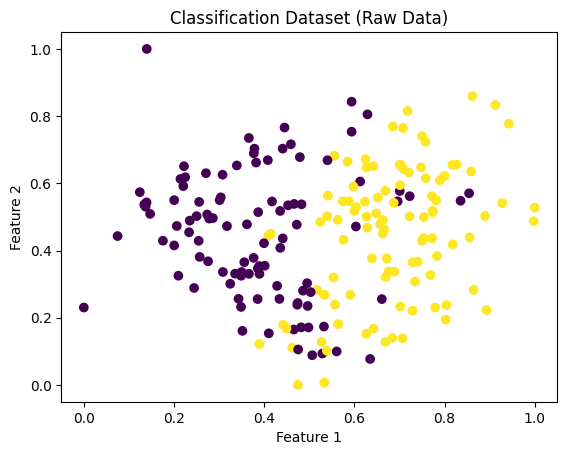

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    X_cls[:, 0],
    X_cls[:, 1],
    c=y_cls.flatten(),
    marker='o'
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Classification Dataset (Raw Data)")
plt.show()


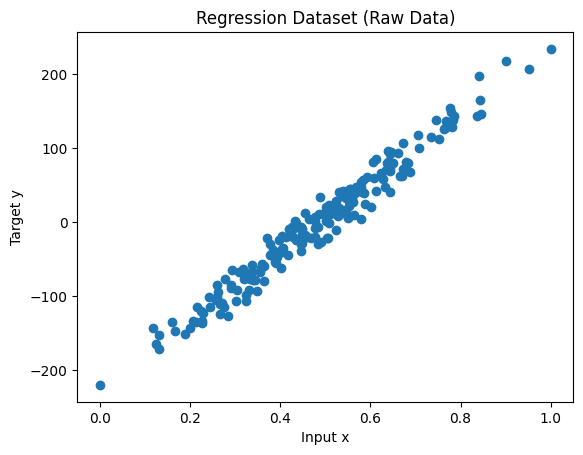

In [36]:
plt.figure()
plt.scatter(
    X_reg.flatten(),
    y_reg.flatten(),
    marker='o'
)
plt.xlabel("Input x")
plt.ylabel("Target y")
plt.title("Regression Dataset (Raw Data)")
plt.show()


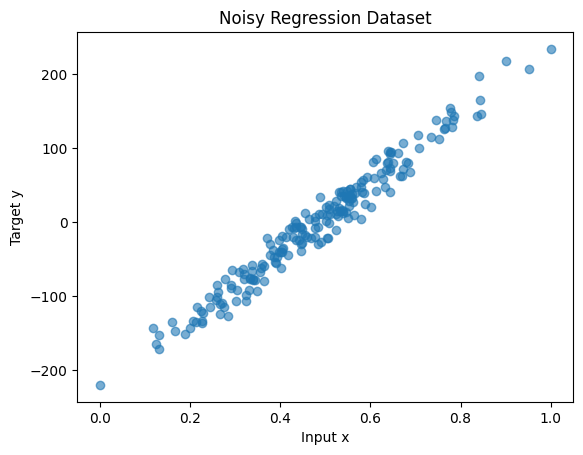

In [37]:
plt.figure()
plt.scatter(
    X_reg.flatten(),
    y_reg.flatten(),
    alpha=0.6,
    marker='o'
)
plt.xlabel("Input x")
plt.ylabel("Target y")
plt.title("Noisy Regression Dataset")
plt.show()


In [38]:
print("=== Classification Dataset Shape ===")
print("X_cls shape:", X_cls.shape)
print("y_cls shape:", y_cls.shape)


=== Classification Dataset Shape ===
X_cls shape: (200, 2)
y_cls shape: (200, 1)


In [39]:
print("\n=== Regression Dataset Shape ===")
print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)



=== Regression Dataset Shape ===
X_reg shape: (200, 1)
y_reg shape: (200, 1)


In [40]:
print("\n=== Classification Dataset Sample ===")
print("X_cls (first 5 rows):")
print(X_cls[:5])
print("y_cls (first 5 rows):")
print(y_cls[:5])



=== Classification Dataset Sample ===
X_cls (first 5 rows):
[[0.80462889 0.23769794]
 [0.77924531 0.23038501]
 [0.34865489 0.23211596]
 [0.1241776  0.57378892]
 [0.75409092 0.49970058]]
y_cls (first 5 rows):
[[1]
 [1]
 [0]
 [0]
 [1]]


In [41]:
print("\n=== Regression Dataset Sample ===")
print("X_reg (first 5 rows):")
print(X_reg[:5])
print("y_reg (first 5 rows):")
print(y_reg[:5])



=== Regression Dataset Sample ===
X_reg (first 5 rows):
[[0.83747099]
 [0.57928599]
 [0.26009421]
 [0.6077649 ]
 [0.47711159]]
y_reg (first 5 rows):
[[143.45082298]
 [ 54.63984844]
 [-84.44223644]
 [ 59.32653116]
 [ -8.24415636]]


In [42]:
print("\n=== Classification Data Statistics ===")
print("X min:", X_cls.min(axis=0))
print("X max:", X_cls.max(axis=0))
print("X mean:", X_cls.mean(axis=0))
print("X std:", X_cls.std(axis=0))



=== Classification Data Statistics ===
X min: [0. 0.]
X max: [1. 1.]
X mean: [0.53436769 0.4479492 ]
X std: [0.20691708 0.19324767]


In [43]:
print("\n=== Regression Data Statistics ===")
print("X min:", X_reg.min())
print("X max:", X_reg.max())
print("X mean:", X_reg.mean())
print("X std:", X_reg.std())



=== Regression Data Statistics ===
X min: 0.0
X max: 1.0
X mean: 0.48296171215302164
X std: 0.17391168503110108
